In [2]:
using Revise
using LinearAlgebra
using PyPlot
using TensorCrossInterpolation
using QuanticsTCI
using QuanticsGrids
using ITensors
using NDTensors
using ITensors
using ITensorMPS
using TCIITensorConversion
import TensorCrossInterpolation as TCI
using Quantics


ITensors.op(::OpName"sigma_plus",::SiteType"Qubit") =
 [0 1
  0 0]

ITensors.op(::OpName"sigma_minus",::SiteType"Qubit") =
 [0 0
  1 0]

function kineticp(L, sites)
    kinetic = OpSum()
    for i in 1:L
        os = OpSum()
        os += 1,"sigma_plus",L-(i-1)

        for i in 1:L-i 
            os *=  ("Id",i) 
        end

        for i in L+2-i :L 
            os *=  ("sigma_minus",i) 
        end
        
        kinetic += os
    end
    return MPO(kinetic,sites)
end


function kineticm(L, sites)
    kinetic = OpSum()
    for i in 1:L
        os = OpSum()
        os += 1,"sigma_minus",L-(i-1)

        for i in 1:L-i 
            os *=  ("Id",i) 
        end

        for i in L+2-i :L 
            os *=  ("sigma_plus",i) 
        end
        
        kinetic += os
    end
    return MPO(kinetic,sites)
end

#the making of trivial hopping MPO
function kinetic(L, sites) 
    kinetic = +(kineticp(L,sites),kineticm(L,sites))
    ITensorMPS.truncate!(kinetic;cutoff=1e-8)
    return kinetic 
end

function kinetic2(L, sites) 
    kinetic = +(apply(kineticp(L,sites),kineticp(L,sites)),apply(kineticm(L,sites),kineticm(L,sites)))
    ITensorMPS.truncate!(kinetic;cutoff=1e-8)
    return kinetic
end

#the KPM process
function KPM_Tn(H,N,sites)
    Ham_n = H/10
    T_k_minus_2 = MPO(sites, "Id")
    T_k_minus_1 = Ham_n   
    Tn_list = [T_k_minus_2,T_k_minus_1]

    for k in 1:N
        if k == 1
            T_k = T_k_minus_2
        elseif k == 2
            T_k = T_k_minus_1
        else
            #truncate to increase efficiency
            T_k = +(2 * apply(Ham_n, T_k_minus_1;cutoff=1e-8) , -T_k_minus_2;  maxdim =100) 
            T_k = ITensorMPS.truncate!(T_k;cutoff=1e-8)
            
            T_k_minus_2 = T_k_minus_1 
            T_k_minus_1 =  T_k    
            push!(Tn_list,T_k)
         
        end
    end
    return Tn_list 
end


#calculation of density matrix
function get_density_from_Tn(Tn_list,N,fermi=0)
       
    jackson_kernel = [(N - n) * cos(π * n / N) + sin(π * n / N) / tan(π / N) for n in 0:N-1]

    function G_n(n)
        if n == 1
            return acos(-fermi)
        else
            return sin((n-1) * acos(fermi)) / (n-1)
        end
    end
    # Compute electronic density
    A = Tn_list[1] * G_n(1) * jackson_kernel[1] 
    for n in 2:N
        A = +(A,  2 *  Tn_list[n] * G_n(n) * jackson_kernel[n] ;maxdim=100)
        A = ITensorMPS.truncate!(A;cutoff=1e-8)
    end
    A /= (π* N)
    
    return  A
end

function quanticsMPSMAT(f, N, qtol)
    qgrid = QuanticsGrids.DiscretizedGrid{2}(Int(log2(N)), (1, 1), (N, N); includeendpoint=true,unfoldingscheme=:interleaved)
    ci, ranks, errors = quanticscrossinterpolate(Float64, f, qgrid; tolerance=qtol)
    println(ranks)
    citt = TensorCrossInterpolation.TensorTrain(ci.tci)
    
    mps_tt_2N = ITensors.MPS(citt)
    return mps_tt_2N
end

#Converts Quantics 2D MPS into MPO
function MPS_to_MPO_Q(mps_2N,N)
    #Contract MPS pairwise
    mps_N = MPS(N)
    for n in 1:N
        A = mps_2N[2n-1]
        B = mps_2N[2n]
        common_link = commonind(A, B)
        if common_link != nothing
            mps_N[n] = A * B
        end
    end
    
    l = linkinds(mps_N)
    
    newsiteinds = Vector{Index{Int64}}(undef, 2N)
    for n in 1:N
        tensor = mps_N[n]          
        # Replace site indices
        c = 0
        new_index = undef
        for site_ind in inds(tensor)
            if (!hastags(site_ind, "link")) && c == 0
                c += 1
                new_index = Index(2, "Site, n=$n")
                tensor = replaceind(tensor, site_ind, new_index)
                newsiteinds[2n - 1] = new_index
            elseif !hastags(site_ind, "link") && c == 1
                tensor = replaceind(tensor, site_ind, prime(new_index))
                newsiteinds[2n] = prime(new_index)
            end
        end
        
        #if n == 1
        #    tensor = replaceind(tensor, l[2], new_links[1])
        #elseif n == N
        #    tensor = replaceind(tensor, l[2(n-1)], new_links[n-1])
        #else
        #    tensor = replaceind(tensor, l[2(n-1)], new_links[n-1])
        #    tensor = replaceind(tensor, l[2n], new_links[n])
        #end
    
        mps_N[n] = tensor
    end

    # Replace link indices

    #Reshape to MPO
    H =  Vector{ITensor}(undef, N)

    for n in 1:N
        if n == 1
            H[n] = mps_N[n]
        elseif n == N
            H[n] = mps_N[n]
        else
            H[n] = mps_N[n]
        end
    end
    mpo = MPO(H)
    sites = [siteinds(mpo)[n][1] for n in 1:N]
    return mpo, sites
end

#Computes |x> from the "site number" n running from 1 to 2^N
function MPS_from_number(sites, n::Int)
    N = length(sites)
    number = n - 1
    # Generate N-bit binary string with leading zeros (MSB-first)
    binary_str = string(number, base=2, pad=N)
    # Reverse only if Quantics grid expects LSB-first (uncomment if needed)
    # binary_str = reverse(binary_str)
    init_states = [bit == '1' ? "1" : "0" for bit in binary_str]
    
    new_sites = siteinds("Qubit", N)
    psi = MPS(new_sites, init_states)
    
    for i in 1:N
        psi[i] = replaceind(psi[i], new_sites[i], sites[i])
    end
    
    return psi
end


#get the density MPS
function get_correlator_quantics(A,L,sites)
    f(x,y) = inner(MPS_from_number(sites, Int(x)),apply(A,MPS_from_number(sites, Int(y))))
    mpo = MPS_to_MPO_Q(quanticsMPSMAT(f, 2^L, 1e-8),L)
    return mpo
end


function get_pos_quantics(L,sites)
    f(x) = div(x + 1, 2)
    xvals = range(1, (2^L); length=2^L)
    qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals ; tolerance=1e-8)
    tt = TCI.tensortrain(qtt.tci)
    density_mps = ITensors.MPS(tt;sites)
    #does not have to be this outer product
    density_mpo = outer(density_mps',density_mps) 
    
    for i in 1:L
        density_mpo.data[i] =  Quantics._asdiagonal(density_mps.data[i],sites[i])
    end
    return density_mpo
end


function get_sz_quantics(L,sites)
    f(x) = (-1)^(x + 1)
    xvals = range(1, (2^L); length=2^L)
    println(xvals)
    qtt, ranks, errors = quanticscrossinterpolate(Float64, f,  xvals ; tolerance=1e-8)
    tt = TCI.tensortrain(qtt.tci)
    density_mps = ITensors.MPS(tt;sites)
    #does not have to be this outer product
    density_mpo = outer(density_mps',density_mps) 
    
    for i in 1:L
        density_mpo.data[i] =  Quantics._asdiagonal(density_mps.data[i],sites[i])
    end
    return density_mpo
end


function SSHham(t1, t2, L, sites)
    K = kinetic(L, sites)
    K2 = kinetic2(L, sites)
    Ham = +(t1*K, t2*K2)
    ITensorMPS.truncate!(Ham;cutoff=1e-8)
    return Ham
end

function checker(mpo, sites, i, j)
    return inner(MPS_from_number(sites, Int(i)),apply(mpo,MPS_from_number(sites, Int(j))))
end

checker (generic function with 1 method)

In [4]:
t1 = 1.
t2 = 0.5
L = 8
sites = siteinds("S=1/2", L)
Id_op = MPO(sites, "Id")
H = SSHham(t1, t2, L, sites)

MPO
[1] ((dim=2|id=203|"S=1/2,Site,n=1")', (dim=2|id=203|"S=1/2,Site,n=1"), (dim=3|id=140|"Link,l=1"))
[2] ((dim=2|id=288|"S=1/2,Site,n=2")', (dim=2|id=288|"S=1/2,Site,n=2"), (dim=3|id=301|"Link,l=2"), (dim=3|id=140|"Link,l=1"))
[3] ((dim=2|id=494|"S=1/2,Site,n=3")', (dim=2|id=494|"S=1/2,Site,n=3"), (dim=3|id=181|"Link,l=3"), (dim=3|id=301|"Link,l=2"))
[4] ((dim=2|id=446|"S=1/2,Site,n=4")', (dim=2|id=446|"S=1/2,Site,n=4"), (dim=3|id=114|"Link,l=4"), (dim=3|id=181|"Link,l=3"))
[5] ((dim=2|id=651|"S=1/2,Site,n=5")', (dim=2|id=651|"S=1/2,Site,n=5"), (dim=3|id=100|"Link,l=5"), (dim=3|id=114|"Link,l=4"))
[6] ((dim=2|id=569|"S=1/2,Site,n=6")', (dim=2|id=569|"S=1/2,Site,n=6"), (dim=3|id=110|"Link,l=6"), (dim=3|id=100|"Link,l=5"))
[7] ((dim=2|id=335|"S=1/2,Site,n=7")', (dim=2|id=335|"S=1/2,Site,n=7"), (dim=3|id=702|"Link,l=7"), (dim=3|id=110|"Link,l=6"))
[8] ((dim=2|id=23|"S=1/2,Site,n=8")', (dim=2|id=23|"S=1/2,Site,n=8"), (dim=3|id=702|"Link,l=7"))


In [5]:
N = 200
Tnlist = KPM_Tn(H,N,sites)
A = get_density_from_Tn(Tnlist,N,0.05)

MPO
[1] ((dim=2|id=203|"S=1/2,Site,n=1")', (dim=2|id=203|"S=1/2,Site,n=1"), (dim=4|id=653|"Link,l=1"))
[2] ((dim=2|id=288|"S=1/2,Site,n=2")', (dim=2|id=288|"S=1/2,Site,n=2"), (dim=5|id=19|"Link,l=2"), (dim=4|id=653|"Link,l=1"))
[3] ((dim=2|id=494|"S=1/2,Site,n=3")', (dim=2|id=494|"S=1/2,Site,n=3"), (dim=7|id=604|"Link,l=3"), (dim=5|id=19|"Link,l=2"))
[4] ((dim=2|id=446|"S=1/2,Site,n=4")', (dim=2|id=446|"S=1/2,Site,n=4"), (dim=11|id=991|"Link,l=4"), (dim=7|id=604|"Link,l=3"))
[5] ((dim=2|id=651|"S=1/2,Site,n=5")', (dim=2|id=651|"S=1/2,Site,n=5"), (dim=19|id=763|"Link,l=5"), (dim=11|id=991|"Link,l=4"))
[6] ((dim=2|id=569|"S=1/2,Site,n=6")', (dim=2|id=569|"S=1/2,Site,n=6"), (dim=14|id=778|"Link,l=6"), (dim=19|id=763|"Link,l=5"))
[7] ((dim=2|id=335|"S=1/2,Site,n=7")', (dim=2|id=335|"S=1/2,Site,n=7"), (dim=4|id=324|"Link,l=7"), (dim=14|id=778|"Link,l=6"))
[8] ((dim=2|id=23|"S=1/2,Site,n=8")', (dim=2|id=23|"S=1/2,Site,n=8"), (dim=4|id=324|"Link,l=7"))


In [6]:
Id_op = MPO(sites, "Id")
x_op = get_pos_quantics(L,sites)
sz = get_sz_quantics(L,sites)

1.0:1.0:256.0


MPO
[1] ((dim=1|id=222|"l=1,link"), (dim=2|id=203|"S=1/2,Site,n=1")', (dim=2|id=203|"S=1/2,Site,n=1"))
[2] ((dim=1|id=222|"l=1,link"), (dim=1|id=613|"l=2,link"), (dim=2|id=288|"S=1/2,Site,n=2")', (dim=2|id=288|"S=1/2,Site,n=2"))
[3] ((dim=1|id=613|"l=2,link"), (dim=1|id=696|"l=3,link"), (dim=2|id=494|"S=1/2,Site,n=3")', (dim=2|id=494|"S=1/2,Site,n=3"))
[4] ((dim=1|id=696|"l=3,link"), (dim=1|id=925|"l=4,link"), (dim=2|id=446|"S=1/2,Site,n=4")', (dim=2|id=446|"S=1/2,Site,n=4"))
[5] ((dim=1|id=925|"l=4,link"), (dim=1|id=155|"l=5,link"), (dim=2|id=651|"S=1/2,Site,n=5")', (dim=2|id=651|"S=1/2,Site,n=5"))
[6] ((dim=1|id=155|"l=5,link"), (dim=1|id=351|"l=6,link"), (dim=2|id=569|"S=1/2,Site,n=6")', (dim=2|id=569|"S=1/2,Site,n=6"))
[7] ((dim=1|id=351|"l=6,link"), (dim=1|id=804|"l=7,link"), (dim=2|id=335|"S=1/2,Site,n=7")', (dim=2|id=335|"S=1/2,Site,n=7"))
[8] ((dim=1|id=804|"l=7,link"), (dim=2|id=23|"S=1/2,Site,n=8")', (dim=2|id=23|"S=1/2,Site,n=8"))


In [13]:
G = Id_op - A
P = Id_op - G
Q = G
T1 = apply(P, apply(x_op, Q))
T2 = apply(Q, apply(x_op, P))
C_op = apply(sz, T1+T2)


function Cr(i)
    i1 = MPS_from_number(sites, Int(2*i-1))
    i2 = MPS_from_number(sites, Int(2*i))
    f1 = inner(i1,apply(C_op,i1))
    f2 = inner(i2,apply(C_op,i2))
    return (f1 + f2)
end

Cr (generic function with 1 method)

In [7]:
vals = [checker(A, sites, i, j) for i in 1:2^L, j in 1:2^L]

256×256 Matrix{Float64}:
  0.338701      0.331167      0.217626     …  -2.08359e-19  -1.26488e-16
  0.331214      0.418269      0.301562         3.21843e-20  -1.04833e-16
  0.217624      0.301595      0.344074        -2.13154e-19  -4.14557e-17
  0.024209      0.115541      0.235563        -9.39961e-19   2.26031e-17
 -0.0999873    -0.0359277     0.119709        -9.76241e-19   5.30884e-17
 -0.099158     -0.0816422     0.0148       …   2.89653e-19   4.20985e-17
 -0.017168     -0.0402469    -0.0418487        2.64485e-18  -5.05263e-18
  0.0589007     0.0247514    -0.0402983        2.86396e-18  -4.26557e-17
  0.0624978     0.0473694    -0.0129905        8.71656e-19  -3.57409e-17
  0.0116249     0.0222367     0.0190755       -2.30172e-18  -9.56643e-18
 -0.0380151    -0.018384      0.022782     …  -6.8121e-18    3.14812e-17
 -0.0444151    -0.03216       0.00766605       9.7011e-19    2.37626e-17
 -0.0083175    -0.0143913    -0.0090373        9.35504e-18   1.79291e-18
  ⋮                       

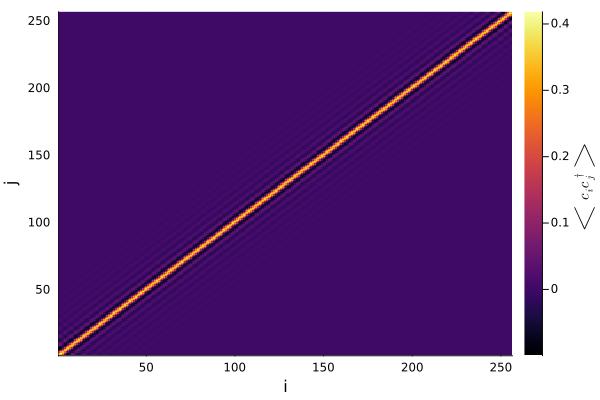

In [12]:
using Plots
heatmap(1:2^L, 1:2^L, vals, xlabel="i", ylabel="j", colorbar_title=raw"$\left<c_i c_j^\dagger\right>$")

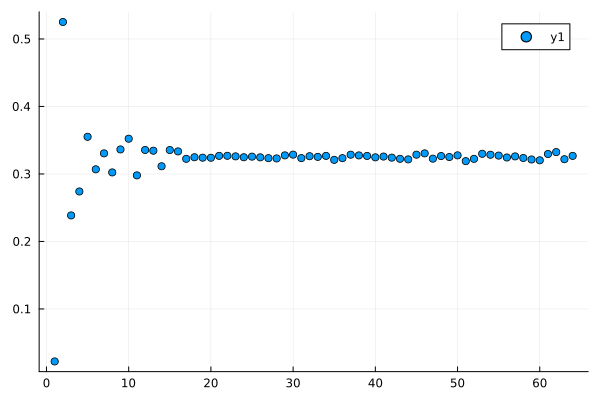

In [15]:
tabplot = [Cr(r) for r in 1:2^(L-2)]
Plots.scatter(1:2^(L-2), tabplot)

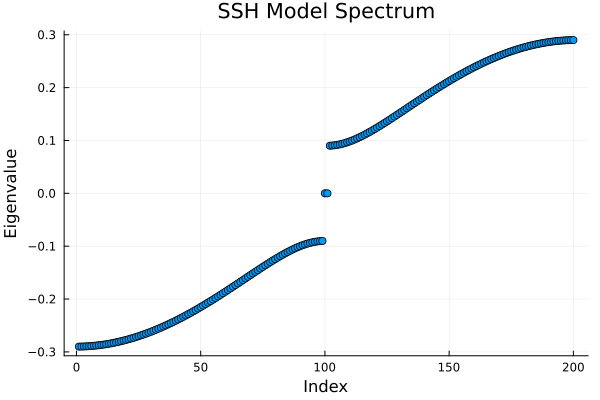

In [269]:
using Plots

# Parameters
p = 100             # Number of unit cells
t1 = 1.0           # Intra-cell hopping
t2 = 1.9          # Inter-cell hopping

q = 2 * p          # Total number of sites

# Initialize the Hamiltonian matrix
H = zeros(Float64, q, q)
for i in 1:2:(q - 1)
    H[i, i+1] = t1
    H[i+1, i] = t1
end
for i in 2:2:(q - 2)
    H[i, i+1] = t2
    H[i+1, i] = t2
end

# Diagonalize the Hamiltonian
eigvals, eigvecs = eigen(H/10)

# Scatter plot the eigenvalues
Plots.scatter(1:q, eigvals, xlabel="Index", ylabel="Eigenvalue", title="SSH Model Spectrum", legend=false)

In [19]:
xi = 1
checker(apply(Q,Q)-Q, sites, xi,xi)/checker(Q, sites, xi,xi)*100

-4.6501106392477345